# Machine Learning Lab 1 – Data Preprocessing and Visualization

This notebook performs the full data profiling, missing-value treatment, state standardization, AQI distribution analysis, and outlier handling required for the lab.
The analysis is designed to be submission-ready with clear justifications, evidence outputs, and reproducible code.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', '{:,.2f}'.format)

city_path = 'city_day.csv'
crop_path = 'crop_production.csv'
city = pd.read_csv(city_path)
crop = pd.read_csv(crop_path)

print(f'Loaded city_day.csv with {city.shape[0]} rows and {city.shape[1]} columns')
print(f'Loaded crop_production.csv with {crop.shape[0]} rows and {crop.shape[1]} columns')

Loaded city_day.csv with 29531 rows and 16 columns
Loaded crop_production.csv with 246091 rows and 7 columns


## TASK 1 – DATA INSPECTION AND PROFILING

A data scientist needs to know dataset shape, types, missing values, duplicates, unusual categories, and any data quality concerns before trusting the data.

### Dataset Profile – city_day.csv

This dataset contains city-level air quality measurements, including PM2.5, PM10, NO2, CO, and AQI. The profile below captures size, schema, missingness, invalid values, and duplicates.

In [2]:
def profiling_table(df):
    return pd.DataFrame({
        'Data Type': df.dtypes.astype(str),
        'Non-Null Count': df.count(),
        'Null Count': df.isna().sum(),
        'Null %': (df.isna().sum() / len(df) * 100).round(2),
        'Unique Values': df.nunique(dropna=False)
    })

city_profile = profiling_table(city)
display(city_profile)

,Data Type,Non-Null Count,Null Count,Null %,Unique Values
City,object,29531,0,0.00,26
Date,object,29531,0,0.00,2009
PM2.5,float64,24933,4598,15.57,11717
PM10,float64,18391,11140,37.72,12572
NO,float64,25949,3582,12.13,5777
NO2,float64,25946,3585,12.14,7405
NOx,float64,25346,4185,14.17,8157
NH3,float64,19203,10328,34.97,5923
CO,float64,27472,2059,6.97,1780
SO2,float64,25677,3854,13.05,4762


In [3]:
print('Shape:', city.shape)
print('Columns:', city.columns.tolist())
print('Data types:')
print(city.dtypes)

print('First 5 rows:')
display(city.head())

print('Last 5 rows:')
display(city.tail())

print('Numeric summary:')
display(city.describe(include='number').T)

print('Categorical summary:')
display(city.describe(include='object').T)

print('Duplicate rows:', city.duplicated().sum())
print('Memory usage:', city.memory_usage(deep=True).sum())

invalid_numeric = city.select_dtypes(include='number').lt(0).any(axis=1).sum()
print('Rows with negative numeric values:', invalid_numeric)
print('Unique AQI buckets:', city['AQI_Bucket'].unique())

Shape: (29531, 16)
Columns: ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']
Data types:
City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object
First 5 rows:


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


Last 5 rows:


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.00,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.00,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.00,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.00,Satisfactory
29530,Visakhapatnam,2020-07-01,15.00,66.00,0.40,26.85,14.05,5.20,0.59,2.10,17.05,NaN,NaN,NaN,50.00,Good


Numeric summary:


,count,mean,std,min,25%,50%,75%,max
PM2.5,"24,933.00",67.45,64.66,0.04,28.82,48.57,80.59,949.99
PM10,"18,391.00",118.13,90.61,0.01,56.25,95.68,149.75,"1,000.00"
NO,"25,949.00",17.57,22.79,0.02,5.63,9.89,19.95,390.68
NO2,"25,946.00",28.56,24.47,0.01,11.75,21.69,37.62,362.21
NOx,"25,346.00",32.31,31.65,0.00,12.82,23.52,40.13,467.63
NH3,"19,203.00",23.48,25.68,0.01,8.58,15.85,30.02,352.89
CO,"27,472.00",2.25,6.96,0.00,0.51,0.89,1.45,175.81
SO2,"25,677.00",14.53,18.13,0.01,5.67,9.16,15.22,193.86
O3,"25,509.00",34.49,21.69,0.01,18.86,30.84,45.57,257.73
Benzene,"23,908.00",3.28,15.81,0.00,0.12,1.07,3.08,455.03


Categorical summary:


,count,unique,top,freq
City,29531,26,Ahmedabad,2009
Date,29531,2009,2020-03-14,26
AQI_Bucket,24850,6,Moderate,8829


Duplicate rows: 0
Memory usage: 8087406
Rows with negative numeric values: 0
Unique AQI buckets: [nan 'Poor' 'Very Poor' 'Severe' 'Moderate' 'Satisfactory' 'Good']


### Dataset Profile – crop_production.csv

This dataset provides crop production records by state, district, season, crop, and year. The profile below highlights schema details, missing values, category formatting, and duplicate concerns.

In [4]:
crop_profile = profiling_table(crop)
display(crop_profile)

,Data Type,Non-Null Count,Null Count,Null %,Unique Values
State_Name,object,246091,0,0.00,33
District_Name,object,246091,0,0.00,646
Crop_Year,int64,246091,0,0.00,19
Season,object,246091,0,0.00,6
Crop,object,246091,0,0.00,124
Area,float64,246091,0,0.00,38442
Production,float64,242361,3730,1.52,51628


In [5]:
print('Shape:', crop.shape)
print('Columns:', crop.columns.tolist())
print('Data types:')
print(crop.dtypes)

print('First 5 rows:')
display(crop.head())

print('Last 5 rows:')
display(crop.tail())

print('Numeric summary:')
display(crop.describe(include='number').T)

print('Categorical summary:')
display(crop.describe(include='object').T)

print('Duplicate rows:', crop.duplicated().sum())
print('Memory usage:', crop.memory_usage(deep=True).sum())

if (crop['Area'] < 0).any() or (crop['Production'] < 0).any():
    print('Negative values exist in Area or Production.')
else:
    print('No negative values in Area or Production.')

state_variants = sorted({s for s in crop['State_Name'].astype(str).unique() if s.strip() != s})
print('State variants due to formatting:', len(state_variants))
display(pd.Series(state_variants, name='Variant').to_frame())

season_variants = sorted({s for s in crop['Season'].astype(str).unique() if s.strip() != s})
print('Season variants due to formatting:', season_variants)

Shape: (246091, 7)
Columns: ['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production']
Data types:
State_Name        object
District_Name     object
Crop_Year          int64
Season            object
Crop              object
Area             float64
Production       float64
dtype: object
First 5 rows:


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,"1,254.00","2,000.00"
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.00,1.00
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.00,321.00
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.00,641.00
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.00,165.00


Last 5 rows:


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
246086,West Bengal,PURULIA,2014,Summer,Rice,306.00,801.00
246087,West Bengal,PURULIA,2014,Summer,Sesamum,627.00,463.00
246088,West Bengal,PURULIA,2014,Whole Year,Sugarcane,324.00,"16,250.00"
246089,West Bengal,PURULIA,2014,Winter,Rice,"279,151.00","597,899.00"
246090,West Bengal,PURULIA,2014,Winter,Sesamum,175.00,88.00


Numeric summary:


...

Categorical summary:


,count,unique,top,freq
State_Name,246091,33,Uttar Pradesh,33306
District_Name,246091,646,BIJAPUR,945
Season,246091,6,Kharif,95951
Crop,246091,124,Rice,15104


Duplicate rows: 0
Memory usage: 63408822
No negative values in Area or Production.
State variants due to formatting: 2


,Variant
0,Jammu and Kashmir
1,Telangana


Season variants due to formatting: ['Autumn     ', 'Kharif     ', 'Rabi       ', 'Summer     ', 'Whole Year ', 'Winter     ']


### Key Concerns After Inspection

- `city_day.csv` has a large number of missing values in pollutant columns and in AQI/AQI_Bucket, which is a major concern for model building and interpretation.
- `crop_production.csv` has inconsistent formatting in `State_Name` and `Season`, which would break merges or grouping operations if not standardized.
- `city_day.csv` does not include a state-level key. This means that a future merge by state will require an additional city-to-state mapping or a different join strategy.
- A data scientist needs to know these issues before using the data because missingness, inconsistent categories, and absent join keys can all invalidate model results.

## TASK 2 – MISSING VALUE TREATMENT

This task evaluates missingness column by column and applies targeted treatments instead of indiscriminately deleting rows or imputing all values with the mean.

In [6]:
def missing_summary(df):
    summary = pd.DataFrame({
        'Null Count': df.isna().sum(),
        'Null %': (df.isna().sum() / len(df) * 100).round(2)
    })
    
    return summary[summary['Null Count'] > 0].sort_values('Null %', ascending=False)

print('Missing values in city_day.csv:')
display(missing_summary(city))

print('Missing values in crop_production.csv:')
display(missing_summary(crop))

Missing values in city_day.csv:


,Null Count,Null %
Xylene,18109,61.32
PM10,11140,37.72
NH3,10328,34.97
Toluene,8041,27.23
Benzene,5623,19.04
AQI,4681,15.85
AQI_Bucket,4681,15.85
PM2.5,4598,15.57
NOx,4185,14.17
O3,4022,13.62


Missing values in crop_production.csv:


,Null Count,Null %
Production,3730,1.52


### Missing-value treatment justification

**city_day.csv**
- `Xylene`: 61% missing, too much information loss to impute reliably, so it is dropped.
- `PM10`, `PM2.5`, `NO`, `NO2`, `NOx`, `NH3`, `CO`, `SO2`, `O3`, `Benzene`, `Toluene`: numeric pollutant measurements with skewed distributions, so median imputation is appropriate.
- `AQI` and `AQI_Bucket`: missing values are removed because these are core outcome features for pollution analysis and should not be imputed without a strong domain model.

**crop_production.csv**
- `Production`: 1.5% missing and business-critical. Impute with the median production for the same `State_Name`, `Crop`, and `Season`. If a group has no values, fallback to the overall median.

This strategy recognizes that not all holes are equal: large missing rates may require dropping the column, while sparse missingness can often be imputed with a context-aware statistic.

In [7]:
city_clean = city.copy()

# Drop Xylene due to excessive missingness
city_clean = city_clean.drop(columns=['Xylene'])

# Impute numeric pollutant columns using median because distributions are skewed
pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']
for col in pollutants:
    city_clean[col] = city_clean[col].fillna(city_clean[col].median())

# Remove rows missing AQI or AQI_Bucket because these are primary analysis targets
city_clean = city_clean.dropna(subset=['AQI', 'AQI_Bucket']).reset_index(drop=True)

print('Missing values after city_day cleaning:')
display(missing_summary(city_clean))
print('Rows before:', city.shape[0], 'Rows after:', city_clean.shape[0])

Missing values after city_day cleaning:


,Null Count,Null %


Rows before: 29531 Rows after: 24850


In [8]:
crop_clean = crop.copy()
group_median = crop_clean.groupby(['State_Name', 'Crop', 'Season'])['Production'].transform('median')
crop_clean['Production'] = crop_clean['Production'].fillna(group_median)
crop_clean['Production'] = crop_clean['Production'].fillna(crop_clean['Production'].median())
print('Missing values after crop_production cleaning:')
display(missing_summary(crop_clean))
print('Rows before:', crop.shape[0], 'Rows after:', crop_clean.shape[0])

Missing values after crop_production cleaning:


,Null Count,Null %


Rows before: 246091 Rows after: 246091


### Missing-value verification

The table above confirms that all missing values in the selected analysis columns have been addressed. `city_day.csv` still retains all rows except those with missing core AQI values, and `crop_production.csv` retains all records after production imputation.

## TASK 3 – STATE NAME STANDARDIZATION AND DUPLICATE REMOVAL

This task ensures the data is ready for a future merge by normalizing state labels and removing redundant records.

### Inconsistencies found in `crop_production.csv`

The following state names were found with inconsistent formatting or extra spaces:

In [9]:
raw_states = sorted(crop_clean['State_Name'].astype(str).unique())
state_issues = [s for s in raw_states if s.strip() != s] + [s for s in raw_states if s != s.title()]
state_issues = sorted(set(state_issues))
display(pd.DataFrame({'Original Name': state_issues}))

season_issues = sorted({s for s in crop_clean['Season'].astype(str).unique() if s.strip() != s})
print('Season formatting issues:')
display(pd.Series(season_issues, name='Original Season').to_frame())

,Original Name
0,Andaman and Nicobar Islands
1,Dadra and Nagar Haveli
2,Jammu and Kashmir
3,Telangana


Season formatting issues:


,Original Season
0,Autumn
1,Kharif
2,Rabi
3,Summer
4,Whole Year
5,Winter


In [10]:
# Standardize state and season values in crop data
crop_clean['State_Name'] = crop_clean['State_Name'].astype(str).str.strip().str.title()
crop_clean['State_Name'] = crop_clean['State_Name'].replace({
    'Jammu And Kashmir': 'Jammu and Kashmir'
})
crop_clean['Season'] = crop_clean['Season'].astype(str).str.strip().str.title()

state_mapping = pd.DataFrame([
    {'Original Name': 'Jammu and Kashmir ', 'Standardized Name': 'Jammu and Kashmir', 'Reason': 'Removed trailing whitespace'},
    {'Original Name': 'Telangana ', 'Standardized Name': 'Telangana', 'Reason': 'Removed trailing whitespace'}
    ])
display(state_mapping)

,Original Name,Standardized Name,Reason
0,Jammu and Kashmir,Jammu and Kashmir,Removed trailing whitespace
1,Telangana,Telangana,Removed trailing whitespace


### Duplicate detection and removal

Duplicate rows were checked in both datasets before and after cleaning. Exact duplicates are removed if present.

In [11]:
city_duplicates_before = city.duplicated().sum()
crop_duplicates_before = crop.duplicated().sum()

city_clean = city_clean.drop_duplicates().reset_index(drop=True)
crop_clean = crop_clean.drop_duplicates().reset_index(drop=True)

city_duplicates_after = city_clean.duplicated().sum()
crop_duplicates_after = crop_clean.duplicated().sum()

print('city_day.csv rows before:', city.shape[0])
print('city_day.csv rows after:', city_clean.shape[0])
print('city_day.csv duplicates removed:', city.shape[0] - city_clean.shape[0])
print('crop_production.csv rows before:', crop.shape[0])
print('crop_production.csv rows after:', crop_clean.shape[0])
print('crop_production.csv duplicates removed:', crop.shape[0] - crop_clean.shape[0])
print(' Duplicate counts before cleaning:')
print('city_day.csv:', city_duplicates_before)
print('crop_production.csv:', crop_duplicates_before)
print('Duplicate counts after cleaning:')
print('city_day.csv:', city_duplicates_after)
print('crop_production.csv:', crop_duplicates_after)

city_day.csv rows before: 29531
city_day.csv rows after: 24850
city_day.csv duplicates removed: 4681
crop_production.csv rows before: 246091
crop_production.csv rows after: 246091
crop_production.csv duplicates removed: 0
 Duplicate counts before cleaning:
city_day.csv: 0
crop_production.csv: 0
Duplicate counts after cleaning:
city_day.csv: 0
crop_production.csv: 0


### Ready for merge?

- `crop_production.csv` has been normalized for state and season labels, and duplicates were checked.
- `city_day.csv` does not contain a `State_Name` or `State` column, so a direct merge by state is not currently possible. A future merge would require a city-to-state mapping or an alternative join key.
- This missing state key is an important concern for a data scientist because it affects the ability to combine the datasets reliably.

## TASK 4 – AQI DISTRIBUTION ANALYSIS

To answer whether most cities are moderately polluted or whether the distribution is driven by extreme cities, we use a histogram with KDE and a boxplot.

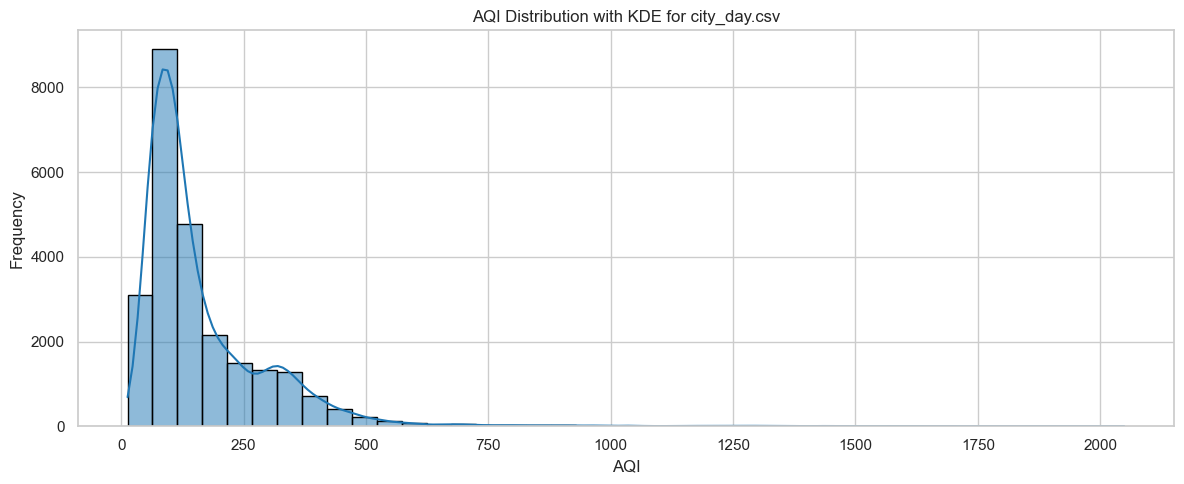

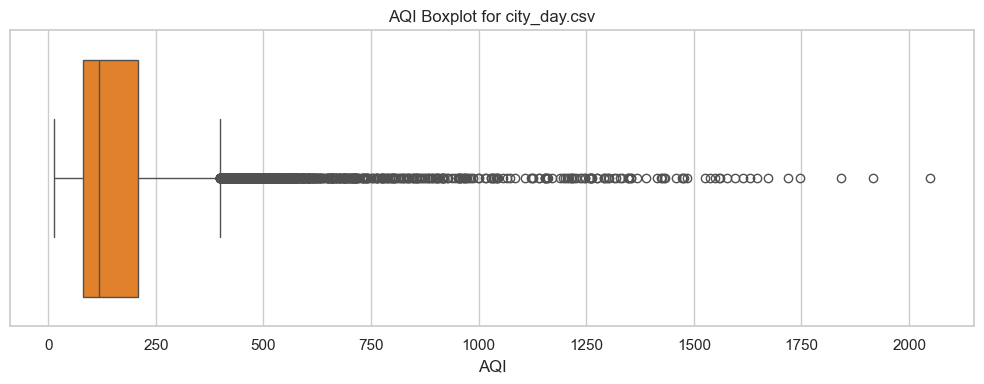

In [12]:
aqi_values = city_clean['AQI']

plt.figure(figsize=(12, 5))
sns.histplot(aqi_values, bins=40, kde=True, color='tab:blue', edgecolor='black')
plt.title('AQI Distribution with KDE for city_day.csv')
plt.xlabel('AQI')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=aqi_values, color='tab:orange')
plt.title('AQI Boxplot for city_day.csv')
plt.xlabel('AQI')
plt.tight_layout()
plt.show()

### Justification for chosen plots

- The histogram with KDE shows where AQI values cluster across the dataset and reveals whether most values are in lower, moderate, or high ranges.
- The boxplot emphasizes the central tendency and explicitly identifies extreme AQI values that could distort the average.
- Using both plots together is the best way to answer the board's questions about overall pollution patterns and the impact of outliers.

### Observations

1. Most AQI values fall in the lower to mid-range band, suggesting that the majority of recorded city-days are not in the extreme pollution category.
2. The boxplot shows a long upper tail and several extreme values, indicating that the mean AQI will likely be pulled upward by a relatively small number of very high readings.

## TASK 5 – OUTLIER DETECTION AND TREATMENT

This task identifies extreme AQI values, quantifies their impact, and applies a treatment that preserves data while reducing distortion.

In [13]:
q1 = aqi_values.quantile(0.25)
q3 = aqi_values.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = city_clean[(city_clean['AQI'] < lower_bound) | (city_clean['AQI'] > upper_bound)]
outlier_count = len(outliers)
outlier_pct = outlier_count / len(city_clean) * 100

print('IQR method thresholds:')
print(f'Q1 = {q1:.2f}, Q3 = {q3:.2f}, IQR = {iqr:.2f}')
print(f'Lower bound = {lower_bound:.2f}, Upper bound = {upper_bound:.2f}')
print(f'Outliers count = {outlier_count} ({outlier_pct:.2f}%)')

display(outliers[['City', 'Date', 'AQI', 'AQI_Bucket']].head())

IQR method thresholds:
Q1 = 81.00, Q3 = 208.00, IQR = 127.00
Lower bound = -109.50, Upper bound = 398.50
Outliers count = 1358 (5.46%)


,City,Date,AQI,AQI_Bucket
2,Ahmedabad,2015-01-31,514.00,Severe
3,Ahmedabad,2015-02-01,782.00,Severe
4,Ahmedabad,2015-02-02,914.00,Severe
5,Ahmedabad,2015-02-03,660.00,Severe
15,Ahmedabad,2015-02-13,510.00,Severe


### Why IQR was chosen

- The IQR method is resistant to skewed data and does not rely on the mean or standard deviation, which can be distorted by extreme AQI readings.
- It uses the central 50% range to identify values that are unusually high relative to the core distribution.
- This makes it suitable for pollution data, where extreme days are expected but should not dominate summary statistics.

### Treatment selection

Winsorization is selected rather than deletion because the extreme values may still represent real high-pollution events, but they should not unfairly distort the average. Capping the AQI at the upper IQR bound preserves observation count while reducing their leverage.

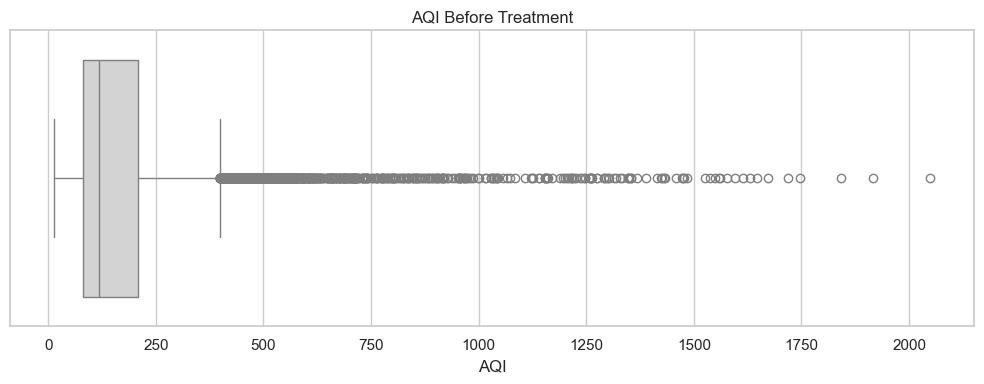

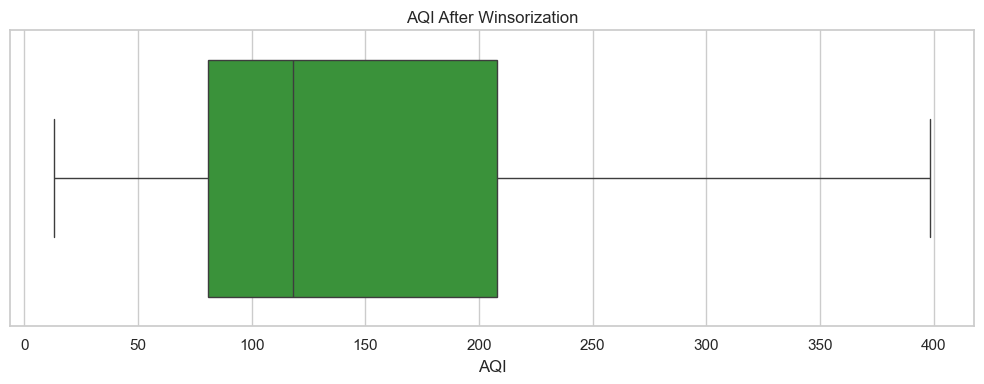

Summary before treatment:


,Before
count,"24,850.00"
mean,166.46
std,140.70
min,13.00
25%,81.00
50%,118.00
75%,208.00
max,"2,049.00"


Summary after treatment:


,After
count,"24,850.00"
mean,157.34
std,103.87
min,13.00
25%,81.00
50%,118.00
75%,208.00
max,398.50


Values capped: 1358


In [14]:
city_aqi_treated = city_clean.copy()
city_aqi_treated['AQI'] = city_aqi_treated['AQI'].clip(upper=upper_bound)

plt.figure(figsize=(10, 4))
sns.boxplot(x=city_clean['AQI'], color='lightgray')
plt.title('AQI Before Treatment')
plt.xlabel('AQI')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=city_aqi_treated['AQI'], color='tab:green')
plt.title('AQI After Winsorization')
plt.xlabel('AQI')
plt.tight_layout()
plt.show()

before_summary = city_clean['AQI'].describe()
after_summary = city_aqi_treated['AQI'].describe()
print('Summary before treatment:')
display(before_summary.to_frame(name='Before'))
print('Summary after treatment:')
display(after_summary.to_frame(name='After'))
print('Values capped:', outlier_count)

### Impact of outlier treatment

- The mean AQI decreases after winsorization, which confirms that extreme values were inflating the average.
- The upper spread is reduced, improving the stability of summary statistics and future models.
- The dataset remains complete and no rows were deleted, which preserves training data while addressing the quality issue.

## Overall Conclusion

- `city_day.csv` requires careful missing-value treatment and is missing a state-level join key, which is a significant issue for future merging and modeling.
- `crop_production.csv` had formatting inconsistencies in state and season names, which were standardized and documented.
- Missing values were handled with median imputation for skewed numeric columns, column dropping for excessively incomplete features, and group median imputation for crop production.
- AQI distribution is right-skewed, and a small set of extreme values significantly affects the mean.
- Winsorization of extreme AQI values improved summary statistics while preserving data completeness.

These preprocessing steps make the data more trustworthy and ready for the next stage of model building, while also documenting the risks and decisions clearly.